In [1]:
from pathlib import Path
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from joblib import Parallel, delayed
import joblib
import nibabel as nib
from nilearn.maskers import NiftiLabelsMasker
from sklearn.decomposition import PCA
from scipy.stats import zscore

In [ ]:

# Define paths
PROJECT_ROOT = Path.cwd().resolve().parent.parent
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "simulation_analysis"

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Preparations

### Loading atlases

In [3]:
# Atlas Loading
def load_atlas(name, filename):
    path = DATA_DIR / "atlases" / filename
    labels_path = DATA_DIR / "atlases" / f"{filename.split('.nii.gz')[0]}_labels.txt"
    return nib.load(path), np.loadtxt(labels_path, dtype=str)

schaefer1000_img, schaefer1000_labels = load_atlas("Schaefer1000", "Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_1mm.nii.gz")
melbourne54_img, melbourne54_labels = load_atlas("Melbourne54", "Tian_Subcortex_S4_3T_1mm.nii.gz")

### Simplified derivation of lesion connectivity maps (ROI-level)

Functions

In [4]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try: yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

def run_extraction(file_paths, method='mean'):
    """
    General function for parallel ROI extraction.
    method='mean' for Z-maps, method='binary' for lesion masks.
    """
    def worker(path):
        try:
            subject = path.stem.split("_infarct")[0]
            
            target = 'data' if method == 'mean' else 'labels'
            
            maskers = [
                NiftiLabelsMasker(labels_img=schaefer1000_img, labels=list(schaefer1000_labels), resampling_target=target, background_label=0),
                NiftiLabelsMasker(labels_img=melbourne54_img, labels=list(melbourne54_labels), resampling_target=target, background_label=0)
            ]
            
            data = [m.fit_transform(str(path)).flatten() for m in maskers]
            combined = np.concatenate(data)
            
            if method == 'binary':
                combined = (combined > 0).astype(int)
                
            return subject, combined
        except: return None

    with tqdm_joblib(tqdm(desc=f"Processing {method}", total=len(file_paths))) as pb:
        results = Parallel(n_jobs=12)(delayed(worker)(p) for p in file_paths)
    
    valid = [r for r in results if r is not None]
    return pd.DataFrame([r[1] for r in valid], index=[r[0] for r in valid], columns=COLUMN_NAMES)

Derive lesion matrix and load C

In [5]:
mask_paths = list((DATA_DIR / "raw" / "lesion_masks" / "acuteinfarct").glob("*.nii.gz"))

if Path(OUTPUTS_DIR / ".." / "lesion_overlap_schaefer1000_roi_data.csv").exists():
    lesion_df = pd.read_csv(OUTPUTS_DIR / ".." / "lesion_overlap_schaefer1000_roi_data.csv", index_col=0)
else:
    lesion_df = run_extraction(mask_paths, method='binary')
    lesion_df.to_csv(OUTPUTS_DIR / "lesion_overlap_schaefer1000_roi_data.csv")

M_real = lesion_df.values

In [6]:
from scipy.io import loadmat

C_path = DATA_DIR / "GSP1000_FC_Schaefer1000Melbourne54.mat"
C = loadmat(C_path)["FC"]

Extract PC1 from the connectome (C)

In [7]:
pca = PCA(n_components=1)
C_z = zscore(C, axis=0)
pc1 = pca.fit_transform(C_z).flatten()
degree = np.sum(C, axis=0)

### Simulation function

In [ ]:
import numpy as np

def run_simulation(
        C, 
        pc1_map, 
        degree_map, 
        seed, 
        n_lesions=50, 
        lesion_size_range=(1,101),
        n_perms=1000, 
        M=None, 
        return_maps=True
):
    
    n_rois = C.shape[0]
    np.random.seed(seed)

    # Use provided lesion matrix or create random ones
    if M is not None:
        # Sample n_lesions from the provided matrix M
        idx = np.random.choice(M.shape[0], n_lesions, replace=True)
        M_sim = M[idx, :]
    else:
        # Create random lesions 
        M_sim = np.zeros((n_lesions, n_rois))
        for i in range(n_lesions):
            # Select a random lesion size within the specified interval
            lesion_size = np.random.randint(lesion_size_range[0], lesion_size_range[1])
            # Select lesion_size random unique ROIs for this specific lesion
            idxs = np.random.choice(n_rois, lesion_size, replace=False)
            M_sim[i, idxs] = 1
     
    L_conn = M_sim @ C 
    
    # sample sv values for each lesion
    sv_rand = np.random.randn(n_lesions)

    # Compute maps
    map_obs = sv_rand.T @ L_conn

    # Permutations (null model)
    sv_perms = np.array([np.random.permutation(sv_rand) for _ in range(n_perms)])
    null_maps = sv_perms @ L_conn
    
    # Z-Map
    null_mean = null_maps.mean(axis=0)
    null_std = null_maps.std(axis=0)
    null_std[null_std == 0] = 1e-9 # avoid division by zero
    map_z = (map_obs - null_mean) / null_std

    # Extract global metrics
    r2_raw_pc1 = np.corrcoef(map_obs, pc1_map)[0,1]**2
    r2_z_pc1 = np.corrcoef(map_z, pc1_map)[0,1]**2
    r2_raw_deg = np.corrcoef(map_obs, degree_map)[0,1]**2
    r2_z_deg = np.corrcoef(map_z, degree_map)[0,1]**2
    
    # Identify significant ROIs and calculate FPR
    is_significant = (np.abs(map_z) > 1.96).astype(int)
    n_sig = np.sum(is_significant)
    fpr = n_sig / n_rois
    
    if return_maps:
        # Track how often each ROI was selected
        selections = M_sim.sum(axis=0)
        return r2_raw_pc1, r2_z_pc1, r2_raw_deg, r2_z_deg, fpr, is_significant, selections
    else:
        return r2_raw_pc1, r2_z_pc1, r2_raw_deg, r2_z_deg, fpr

## Simulation using random lesions

In [9]:
n_simulations = 10000

# Run the parallel simulation
results = Parallel(n_jobs=-1, verbose=0)(
    delayed(run_simulation)(C, pc1, degree, seed, n_lesions=50, 
                            lesion_size_range=(1,51), M=None, 
                            return_maps=False) 
    for seed in np.array(range(n_simulations))
)

# Unpack the results
metrics = [res for res in results]

# Create metrics DataFrame
df_results_rand = pd.DataFrame(metrics, columns=["R2_Raw_PC1", "R2_Z_Map_PC1", "R2_Raw_Degree", "R2_Z_Map_Degree", "FPR"])
df_results_rand["FPR_Percent"] = df_results_rand["FPR"] * 100
mean_fpr_pct = df_results_rand["FPR_Percent"].mean()
print(f"Mean FPR: {mean_fpr_pct:.3f}%")

Mean FPR: 4.946%


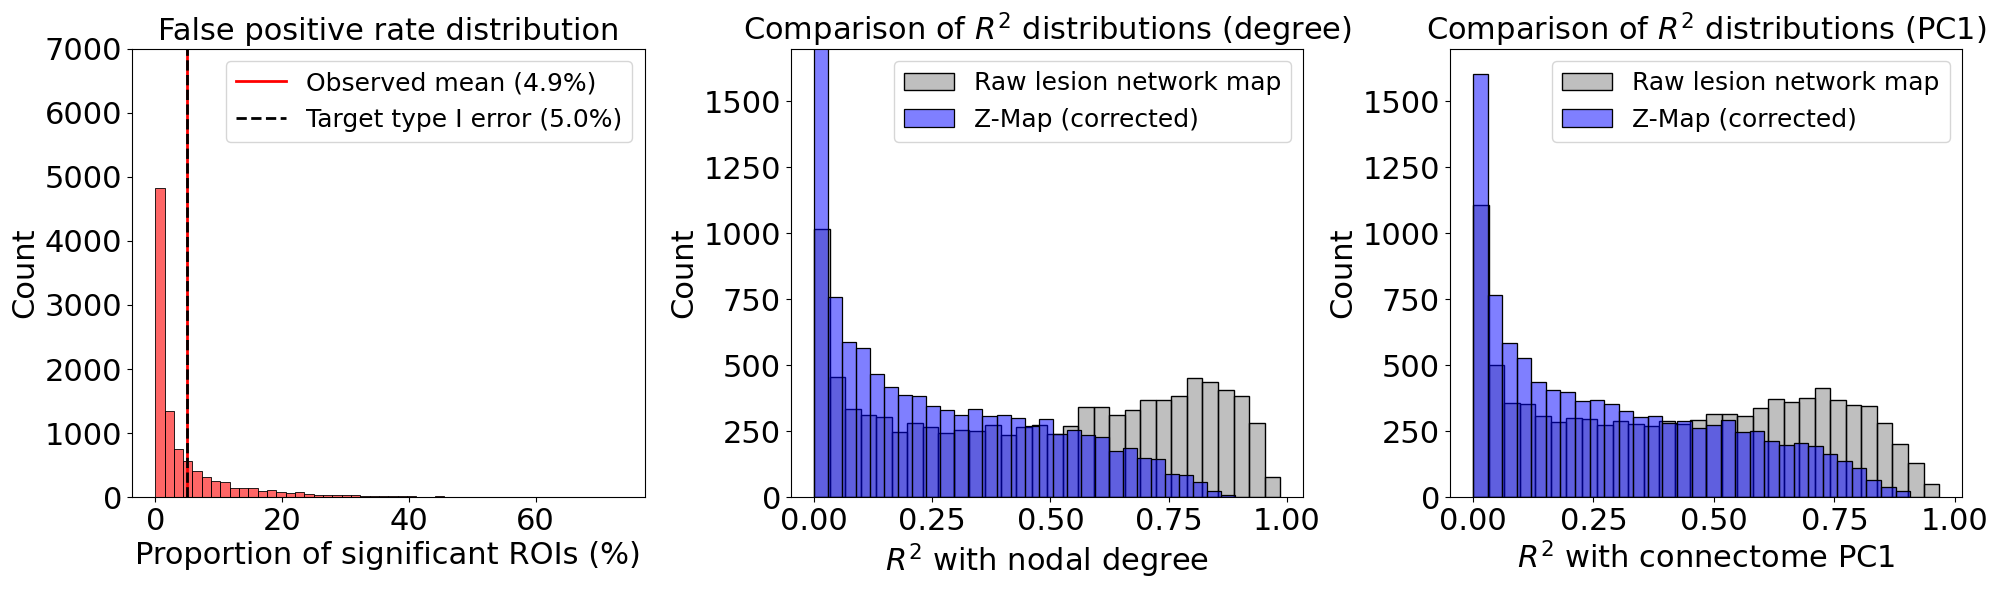

In [10]:
fontsize = 22

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: FPR distribution (Left facet)
sns.histplot(df_results_rand["FPR_Percent"], color="red", ax=axes[0], bins=50, alpha=0.6)

axes[0].axvline(mean_fpr_pct, color='red', linestyle='-', linewidth=2, label=f"Observed mean ({mean_fpr_pct:.1f}%)")
axes[0].axvline(5.0, color='black', linestyle='--', linewidth=2, label="Target type I error (5.0%)")
axes[0].set_title("False positive rate distribution", fontsize=fontsize)
axes[0].set_xlabel("Proportion of significant ROIs (%)", fontsize=fontsize)
axes[0].set_ylabel("Count", fontsize=fontsize)
axes[0].set_ylim(0, 7000)
axes[0].tick_params(axis='both', which='major', labelsize=fontsize)
axes[0].legend(fontsize=fontsize - 4)

# Plot 2: R-squared distribution for Degree (Middle facet)
sns.histplot(df_results_rand["R2_Raw_Degree"], color="gray", label="Raw lesion network map", ax=axes[1], alpha=0.5, bins=30)
sns.histplot(df_results_rand["R2_Z_Map_Degree"], color="blue", label="Z-Map (corrected)", ax=axes[1], alpha=0.5, bins=30)

axes[1].set_title("Comparison of $R^2$ distributions (degree)", fontsize=fontsize)
axes[1].set_xlabel("$R^2$ with nodal degree", fontsize=fontsize)
axes[1].set_ylabel("Count", fontsize=fontsize)
axes[1].set_ylim(0, 1700)
axes[1].tick_params(axis='both', which='major', labelsize=fontsize)
axes[1].legend(fontsize=fontsize - 4)

# Plot 3: R-squared distribution for PC1 (Right facet)
sns.histplot(df_results_rand["R2_Raw_PC1"], color="gray", label="Raw lesion network map", ax=axes[2], alpha=0.5, bins=30)
sns.histplot(df_results_rand["R2_Z_Map_PC1"], color="blue", label="Z-Map (corrected)", ax=axes[2], alpha=0.5, bins=30)

axes[2].set_title("Comparison of $R^2$ distributions (PC1)", fontsize=fontsize)
axes[2].set_xlabel("$R^2$ with connectome PC1", fontsize=fontsize)
axes[2].set_ylabel("Count", fontsize=fontsize)
axes[2].set_ylim(0, 1700)
axes[2].tick_params(axis='both', which='major', labelsize=fontsize)
axes[2].legend(fontsize=fontsize - 4)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "simulation_validation_results_rand.png", dpi=300)
plt.show()

## Simulation using real lesions

In [11]:
n_simulations = 10000

# Run the parallel simulation ONCE
results = Parallel(n_jobs=-1, verbose=0)(
    delayed(run_simulation)(C, pc1, degree, seed, M=M_real, return_maps=False) 
    for seed in np.array(range(n_simulations))
)

# Unpack the results
metrics = [res for res in results]

# Create metrics DataFrame
df_results_real = pd.DataFrame(metrics, columns=["R2_Raw_PC1", "R2_Z_Map_PC1", "R2_Raw_Degree", "R2_Z_Map_Degree", "FPR"])
df_results_real["FPR_Percent"] = df_results_real["FPR"] * 100
mean_fpr_pct = df_results_real["FPR_Percent"].mean()
print(f"Mean FPR: {mean_fpr_pct:.3f}%")

Mean FPR: 4.936%


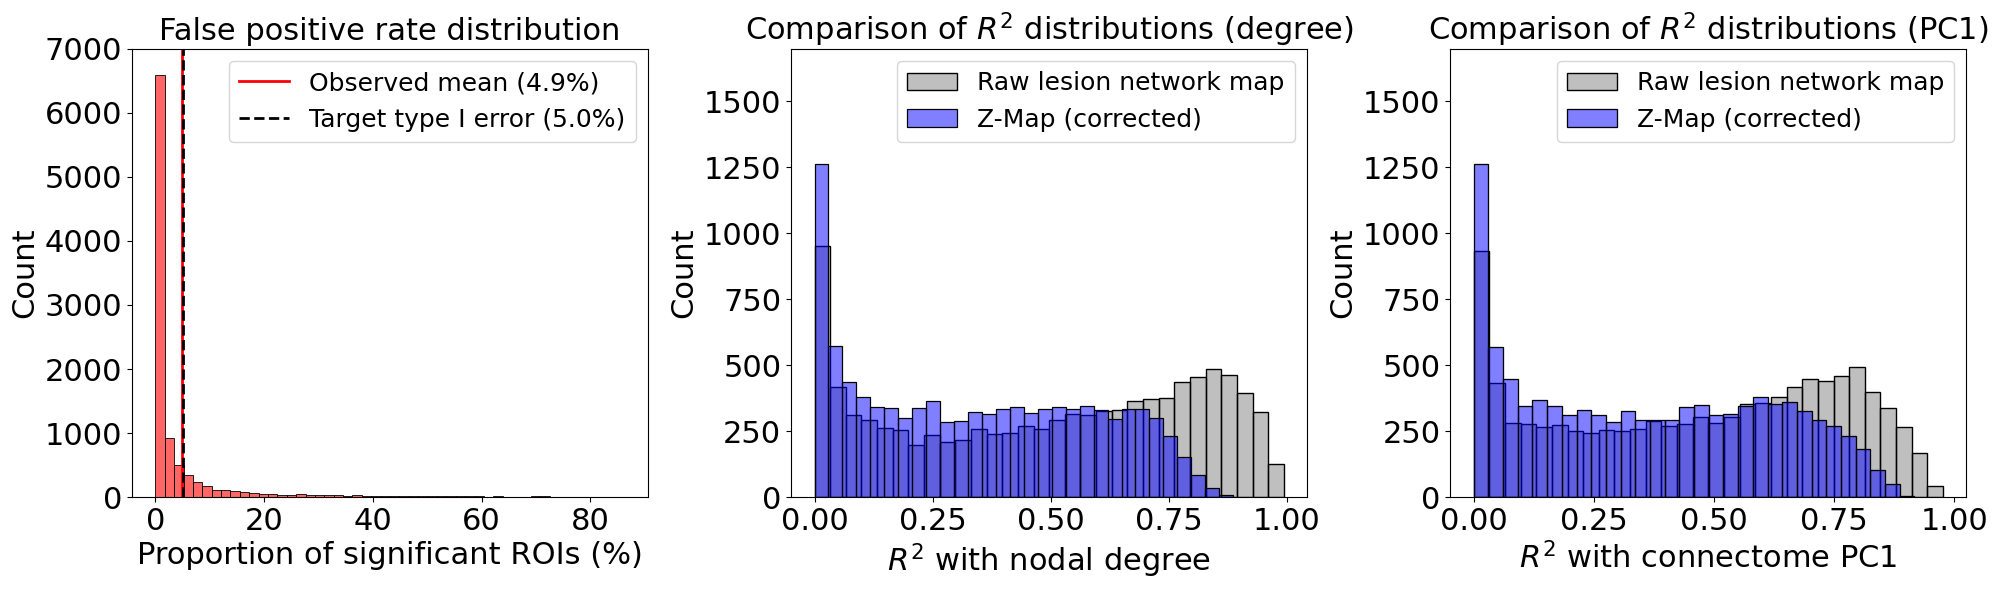

In [12]:
fontsize = 22

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: FPR distribution (Left facet)
sns.histplot(df_results_real["FPR_Percent"], color="red", ax=axes[0], bins=50, alpha=0.6)

axes[0].axvline(mean_fpr_pct, color='red', linestyle='-', linewidth=2, label=f"Observed mean ({mean_fpr_pct:.1f}%)")
axes[0].axvline(5.0, color='black', linestyle='--', linewidth=2, label="Target type I error (5.0%)")
axes[0].set_title("False positive rate distribution", fontsize=fontsize)
axes[0].set_xlabel("Proportion of significant ROIs (%)", fontsize=fontsize)
axes[0].set_ylabel("Count", fontsize=fontsize)
axes[0].set_ylim(0, 7000)
axes[0].tick_params(axis='both', which='major', labelsize=fontsize)
axes[0].legend(fontsize=fontsize - 4)

# Plot 2: R-squared distribution for Degree (Middle facet)
sns.histplot(df_results_real["R2_Raw_Degree"], color="gray", label="Raw lesion network map", ax=axes[1], alpha=0.5, bins=30)
sns.histplot(df_results_real["R2_Z_Map_Degree"], color="blue", label="Z-Map (corrected)", ax=axes[1], alpha=0.5, bins=30)

axes[1].set_title("Comparison of $R^2$ distributions (degree)", fontsize=fontsize)
axes[1].set_xlabel("$R^2$ with nodal degree", fontsize=fontsize)
axes[1].set_ylabel("Count", fontsize=fontsize)
axes[1].set_ylim(0, 1700)
axes[1].tick_params(axis='both', which='major', labelsize=fontsize)
axes[1].legend(fontsize=fontsize - 4)

# Plot 3: R-squared distribution for PC1 (Right facet)
sns.histplot(df_results_real["R2_Raw_PC1"], color="gray", label="Raw lesion network map", ax=axes[2], alpha=0.5, bins=30)
sns.histplot(df_results_real["R2_Z_Map_PC1"], color="blue", label="Z-Map (corrected)", ax=axes[2], alpha=0.5, bins=30)

axes[2].set_title("Comparison of $R^2$ distributions (PC1)", fontsize=fontsize)
axes[2].set_xlabel("$R^2$ with connectome PC1", fontsize=fontsize)
axes[2].set_ylabel("Count", fontsize=fontsize)
axes[2].set_ylim(0, 1700)
axes[2].tick_params(axis='both', which='major', labelsize=fontsize)
axes[2].legend(fontsize=fontsize - 4)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "simulation_validation_results_real.png", dpi=300)
plt.show()